In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
import cv2


import matplotlib.pyplot as plt
import seaborn as sns


import os
from pathlib import Path
from PIL import Image 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import os
from tensorflow.keras import layers, models, callbacks



In [2]:
# ==============================
# DATASET PATHS
# ==============================

BASE_DIR = Path("archive")

IMAGE_DIR = BASE_DIR / "road_line_images"
ANNOTATION_DIR = BASE_DIR / "road_line_annotation"

print("Image folder:", IMAGE_DIR)
print("Annotation folder:", ANNOTATION_DIR)

print("Images exist:", IMAGE_DIR.exists())
print("Annotations exist:", ANNOTATION_DIR.exists())

Image folder: archive\road_line_images
Annotation folder: archive\road_line_annotation
Images exist: True
Annotations exist: True


In [3]:
# ==============================
# CHECK DATASET
# ==============================

image_files = list(IMAGE_DIR.glob("*"))

annotation_files = list(ANNOTATION_DIR.glob("*"))

print("Total images:", len(image_files))
print("Total annotations:", len(annotation_files))

print("\nSample images:")
for file in image_files[:5]:
    print(file.name)

print("\nSample annotations:")
for file in annotation_files[:5]:
    print(file.name)

Total images: 1
Total annotations: 1

Sample images:
road_line_images

Sample annotations:
road_line_annotation


Valid image files: 50
✅ Image found: archive\road_line_images\road_line_images\dc_auto_000177_QW8Pqnw0.jpg
Image shape: (4160, 3120, 3)


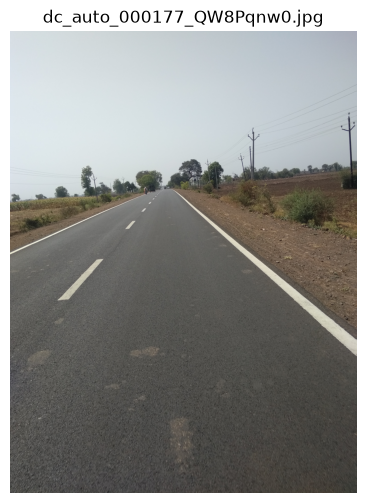

In [5]:
# ==============================
# FIND A VALID IMAGE
# ==============================

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    file for file in IMAGE_DIR.rglob("*")
    if file.is_file() and file.suffix.lower() in valid_extensions
]

print("Valid image files:", len(image_files))

# Find first image that OpenCV can actually read
sample_image = None
img = None

for file in image_files:
    temp = cv2.imread(str(file))

    if temp is not None:
        sample_image = file
        img = temp
        break

if img is None:
    print("❌ No readable image found!")
else:
    print("✅ Image found:", sample_image)
    print("Image shape:", img.shape)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(sample_image.name)
    plt.axis("off")
    plt.show()

In [6]:
def detect_lanes(image):

    # Resize for low laptop load
    height, width = image.shape[:2]

    new_width = 640
    new_height = int(height * new_width / width)

    image = cv2.resize(image, (new_width, new_height))

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Blur
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Edge detection
    edges = cv2.Canny(blur, 50, 150)

    # Region of Interest
    h, w = edges.shape

    mask = np.zeros_like(edges)

    roi = np.array([[
        (0, h),
        (int(0.40 * w), int(0.55 * h)),
        (int(0.60 * w), int(0.55 * h)),
        (w, h)
    ]], dtype=np.int32)

    cv2.fillPoly(mask, roi, 255)

    cropped_edges = cv2.bitwise_and(edges, mask)

    # Hough Line Detection
    lines = cv2.HoughLinesP(
        cropped_edges,
        1,
        np.pi / 180,
        threshold=40,
        minLineLength=40,
        maxLineGap=100
    )

    left_lines = []
    right_lines = []

    if lines is not None:

        for line in lines:

            x1, y1, x2, y2 = line[0]

            if x2 == x1:
                continue

            slope = (y2 - y1) / (x2 - x1)

            # Ignore horizontal lines
            if abs(slope) < 0.5:
                continue

            if slope < 0:
                left_lines.append((x1, y1, x2, y2))
            else:
                right_lines.append((x1, y1, x2, y2))

    # Draw lane line
    def draw_line(lines, color):

        if len(lines) == 0:
            return

        points_x = []
        points_y = []

        for x1, y1, x2, y2 in lines:
            points_x.extend([x1, x2])
            points_y.extend([y1, y2])

        if len(points_x) < 2:
            return

        slope, intercept = np.polyfit(points_x, points_y, 1)

        y1 = h
        y2 = int(0.55 * h)

        if slope == 0:
            return

        x1 = int((y1 - intercept) / slope)
        x2 = int((y2 - intercept) / slope)

        cv2.line(
            image,
            (x1, y1),
            (x2, y2),
            color,
            7
        )

    # Blue = left lane
    draw_line(left_lines, (255, 0, 0))

    # Green = right lane
    draw_line(right_lines, (0, 255, 0))

    # Label
    cv2.putText(
        image,
        "LANE DETECTION",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    return image

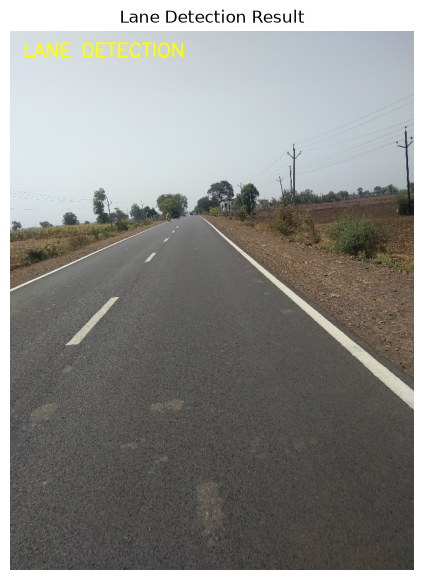

In [7]:
# Read the already verified image
img = cv2.imread(str(sample_image))

# Detect lanes
result = detect_lanes(img)

# Convert BGR -> RGB
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(result_rgb)
plt.title("Lane Detection Result")
plt.axis("off")
plt.show()

In [11]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Camera could not be opened")
else:
    print("✅ Camera started")
    print("Press Q to stop")

    while True:

        ret, frame = cap.read()

        if not ret:
            print("❌ Could not read frame")
            break

        # Lane detection
        result = detect_lanes(frame)

        # Show camera
        cv2.imshow("DriveSense AI - Lane Detection", result)

        # Press Q to stop
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

✅ Camera started
Press Q to stop
❌ Could not read frame
